# Generación de texto con redes recurrentes

## Configuraciones iniciales

### Carga de librerías

In [ ]:
import tensorflow as tf

import numpy as np
import os
import time

### Descarga del dataset de obras de Shakespeare

Para utilizar otro set de datos (puede ser propio), basta cambiar esta línea

In [ ]:
path_to_file = tf.keras.utils.get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Revisando los datos

In [ ]:
text = open(path_to_file, 'rb').read().decode(encoding='utf-8')
print('Length of text: {} characters'.format(len(text)))

Length of text: 1115394 characters


In [ ]:
print(text[:250])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [ ]:
# Caracteres únicos en el archivo (usaremos esto para formar el vocabulario)
vocab = sorted(set(text))
print('{} unique characters'.format(len(vocab)))

65 unique characters


## Preprocesamiento del texto
Los siguientes pasos son comunes a casi todas las aplicaciones que trabajan con texto, por lo que la mayoría de las veces no es necesario hacer cambio alguno.

### Vectorización

Acá pasaremos los strings a una representación numérica para que pueda ser procesada posteriormente por la red.

In [ ]:
char2idx = {u:i for i, u in enumerate(vocab)}
idx2char = np.array(vocab)

text_as_int = np.array([char2idx[c] for c in text])

In [ ]:
print('{')
for char,_ in zip(char2idx, range(20)):
    print('  {:4s}: {:3d},'.format(repr(char), char2idx[char]))
print('  ...\n}')

{
  '\n':   0,
  ' ' :   1,
  '!' :   2,
  '$' :   3,
  '&' :   4,
  "'" :   5,
  ',' :   6,
  '-' :   7,
  '.' :   8,
  '3' :   9,
  ':' :  10,
  ';' :  11,
  '?' :  12,
  'A' :  13,
  'B' :  14,
  'C' :  15,
  'D' :  16,
  'E' :  17,
  'F' :  18,
  'G' :  19,
  ...
}


In [ ]:
print('{} ---- characters mapped to int ---- > {}'.format(repr(text[:13]), text_as_int[:13]))

'First Citizen' ---- characters mapped to int ---- > [18 47 56 57 58  1 15 47 58 47 64 43 52]


### Configurando la tarea de predicción

La tarea que intentaremos resolver es la siguiente: dada una secuencia de caracteres, predecir el siguiente carácter de esta (tarea autosupervisada). Con el fin de utilizar la mayor cantidad posible de información, por cada carácter procesado, la red deberá generar el siguiente, es decir, no espera a completar una cierta cantidad de caracteres antes de predecir.

Para esto necesitamos configurar adecuadamente el set de datos y los batches para SGD. Al igual que antes, la gran mayoría de este código se puede reusar para otras tareas de predicción similares.


### Creación de ejemplos y objetivos (X e y)

Para facilitar el procesamiento, crearemos secuencias de tamaño fijo como ejemplos (largo 100), y por cada una el objetivo será la misma secuencia con un desfase de una posición, con el fin de que se prediga (y penalice) el siguiente carácter.

En la práctica, dividiremos el texto en secuencias de largo 101, donde los primeros 100 caracteres serán el ejemplo y los últimos 100 el objetivo.

In [ ]:
seq_length = 100
examples_per_epoch = len(text)//(seq_length+1)

char_dataset = tf.data.Dataset.from_tensor_slices(text_as_int)

for i in char_dataset.take(5):
    print(idx2char[i.numpy()])

F
i
r
s
t


In [ ]:
sequences = char_dataset.batch(seq_length+1, drop_remainder=True)

for item in sequences.take(5):
    print(repr(''.join(idx2char[item.numpy()])))

'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou '
'are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you k'
"now Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us ki"
"ll him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be d"
'one: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor citi'


In [ ]:
def split_input_target(chunk):
    input_text = chunk[:-1]
    target_text = chunk[1:]
    return input_text, target_text

dataset = sequences.map(split_input_target)

In [ ]:
for input_example, target_example in  dataset.take(1):
    print('Input data: ', repr(''.join(idx2char[input_example.numpy()])))
    print('Target data:', repr(''.join(idx2char[target_example.numpy()])))

Input data:  'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou'
Target data: 'irst Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou '


### Creando los batches para SGD

In [ ]:
# Batch size
BATCH_SIZE = 64

# Buffer size to shuffle the dataset
# (TF data is designed to work with possibly infinite sequences,
# so it doesn't attempt to shuffle the entire sequence in memory. Instead,
# it maintains a buffer in which it shuffles elements).
BUFFER_SIZE = 10000

dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

dataset

<_BatchDataset element_spec=(TensorSpec(shape=(64, 100), dtype=tf.int64, name=None), TensorSpec(shape=(64, 100), dtype=tf.int64, name=None))>

## Construyendo el modelo

In [ ]:
vocab_size = len(vocab)
embedding_dim = 256
rnn_units = 1024

In [ ]:
# def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
#     model = tf.keras.Sequential([
#         tf.keras.layers.Embedding(vocab_size, embedding_dim,
#                                   batch_input_shape=[batch_size, None]),
#         tf.keras.layers.SimpleRNN(rnn_units,
#                             return_sequences=True,
#                             stateful=True,
#                             recurrent_initializer='glorot_uniform'),
#         tf.keras.layers.SimpleRNN(rnn_units,
#                             return_sequences=True,
#                             stateful=True,
#                             recurrent_initializer='glorot_uniform'),
#         tf.keras.layers.Dense(vocab_size)
#     ])
#     return model

In [ ]:
############# CORREGIDO ###############

def build_model(vocab_size, embedding_dim, rnn_units, batch_size):
    inputs = tf.keras.Input(batch_shape=(batch_size, None))  # batch_size fijo aquí

    x = tf.keras.layers.Embedding(vocab_size, embedding_dim)(inputs)

    x = tf.keras.layers.SimpleRNN(
        rnn_units,
        return_sequences=True,
        stateful=True,
        recurrent_initializer='glorot_uniform'
    )(x)

    x = tf.keras.layers.SimpleRNN(
        rnn_units,
        return_sequences=True,
        stateful=True,
        recurrent_initializer='glorot_uniform'
    )(x)

    outputs = tf.keras.layers.Dense(vocab_size)(x)

    model = tf.keras.Model(inputs, outputs)
    return model

In [ ]:
model = build_model(
    vocab_size=len(vocab),
    embedding_dim=embedding_dim,
    rnn_units=rnn_units,
    batch_size=BATCH_SIZE)

![](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/text/images/text_generation_training.png?raw=1)

## Probando el modelo (sin entrenar aún)

Esto nos permite verificar que todos los tamaños y tipos de dato que retorna la red son correctos. Siempre es recomendable hacer esto con modelos complejos antes de entrenarlos.

In [ ]:
for input_example_batch, target_example_batch in dataset.take(1):
    example_batch_predictions = model(input_example_batch)
    print(example_batch_predictions.shape, "# (batch_size, sequence_length, vocab_size)")

(64, 100, 65) # (batch_size, sequence_length, vocab_size)


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (64, None)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (64, None, 256)        │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (64, None, 1024)       │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (64, None, 1024)       │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (64, None, 65)         │        66,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,493,185 (13.33 MB)

 Trainable params: 3,493,185 (13.33 MB)

 Non-trainable params: 0 (0.00 B)

Acá probamos si las predicciones son efectivamente caracteres (no tienen que tener sentido, pq el modelo no ha sido aún entrenado)

In [ ]:
sampled_indices = tf.random.categorical(example_batch_predictions[0], num_samples=1)
sampled_indices = tf.squeeze(sampled_indices,axis=-1).numpy()

In [ ]:
sampled_indices

array([23, 20,  6, 64, 49,  8, 49, 44, 43,  2, 58, 56, 53, 32, 27, 20, 13,
       26, 31, 47, 28, 10, 20,  0,  7, 34, 12, 37, 21, 23, 19, 56, 46, 49,
       27, 22, 34, 40, 18, 53, 15, 64, 52, 28, 10, 37, 37, 44, 10, 36, 57,
       35, 20, 26, 19, 53, 61, 64,  5, 59, 39, 42,  0, 33,  0, 46, 26, 11,
        7, 62, 38, 50, 35,  3, 61,  1, 62, 31, 10, 61, 43, 39,  6, 45, 41,
       54, 56, 60, 59, 19, 29, 50,  3, 28,  7, 22, 10, 36, 28, 55])

In [ ]:
print("Input: \n", repr("".join(idx2char[input_example_batch[0]])))
print()
print("Next Char Predictions: \n", repr("".join(idx2char[sampled_indices ])))

Input: 
 'dare break with us.\n\nMENENIUS:\nCannot be!\nWe have record that very well it can,\nAnd three examples o'

Next Char Predictions: 
 "KH,zk.kfe!troTOHANSiP:H\n-V?YIKGrhkOJVbFoCznP:YYf:XsWHNGowz'uad\nU\nhN;-xZlW$w xS:wea,gcprvuGQl$P-J:XPq"


## Entrenando el modelo

In [ ]:
def loss(labels, logits):
    return tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)

example_batch_loss = loss(target_example_batch, example_batch_predictions)
print("Prediction shape: ", example_batch_predictions.shape, " # (batch_size, sequence_length, vocab_size)")
print("scalar_loss:      ", example_batch_loss.numpy().mean())

Prediction shape:  (64, 100, 65)  # (batch_size, sequence_length, vocab_size)
scalar_loss:       4.2575545


In [ ]:
model.compile(optimizer='adam', loss=loss)

### Configurando checkpoints para salvar el estado del modelo durante el entrenamiento

In [ ]:
# Directory where the checkpoints will be saved
checkpoint_dir = './training_checkpoints'
# Name of the checkpoint files
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt_{epoch}.weights.h5") #se agrega .weights.h5

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_prefix,
    save_weights_only=True)

### Executando el entrenamiento

In [ ]:
EPOCHS = 10

In [ ]:
history = model.fit(dataset, epochs=EPOCHS, callbacks=[checkpoint_callback])

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - loss: 3.6802
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 40s 108ms/step - loss: 2.2640
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 1.9482
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 1.7752
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 1.6614
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 1.5836
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 111ms/step - loss: 1.5310
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 41s 113ms/step - loss: 1.4888
Epoch 9/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - loss: 1.4568
Epoch 10/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - loss: 1.4336


A continuación, se presenta un gráfico con el comportamiento de la función de pérdida.

In [ ]:
print(history.history.keys())

dict_keys(['loss'])


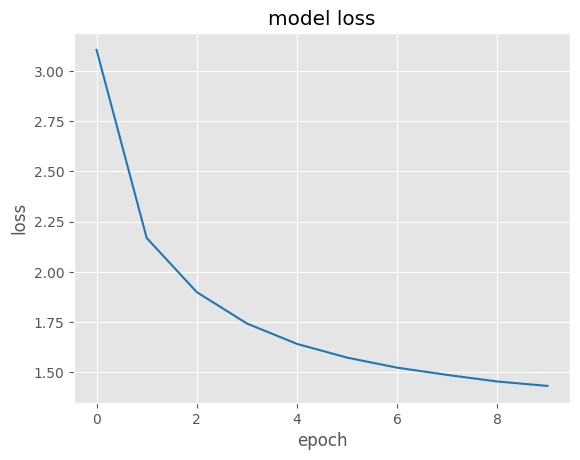

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
# Para función de pérdida
plt.plot(history.history['loss'], color = "tab:blue")
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

## Generando texto

### Restaurando el último checkpoint

Para mantener la etapa de predicción entendible, utilizaremos un batch de 1 (esto es solo para la predicción, el entrenamiento sigue usando batch_size de 64).

El problema con hacer este cambio es que los modelos no soportan cambiar el tamaño del batch una vez que fueron entrenados. Para solucionar este problema, basta con reconstruir el modelo con un nuevo tamaño de batch, pero cargando como pesos iniciales lo obtenidos al finalizar el entrenamiento.

In [ ]:
import glob
import os

In [ ]:
################### CORREGIDO ##################
latest_checkpoint = max(glob.glob(os.path.join(checkpoint_dir, "*.weights.h5")), key=os.path.getctime)

model = build_model(vocab_size, embedding_dim, rnn_units, batch_size=1)
model.load_weights(latest_checkpoint)

In [ ]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (1, None)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (1, None, 256)         │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (1, None, 1024)        │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (1, None, 1024)        │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, None, 65)          │        66,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,493,185 (13.33 MB)

 Trainable params: 3,493,185 (13.33 MB)

 Non-trainable params: 0 (0.00 B)

### El ciclo de predicción
![](https://github.com/tensorflow/docs/blob/master/site/en/tutorials/text/images/text_generation_sampling.png?raw=1)

Se define la función para reiniciar estados.

In [ ]:
def reset_rnn_states(model):
    for layer in model.layers:
        if hasattr(layer, 'reset_states'):
            layer.reset_states()

In [ ]:
############# CORREGIDO #################


def generate_text(model, start_string):
    num_generate = 1000

    input_eval = [char2idx[s] for s in start_string]
    input_eval = tf.expand_dims(input_eval, 0)

    text_generated = []

    # El parámetro de temperatura se relaciona con el nivel de predictibilidad
    # del texto. Temperaturas altas generan texto más "sorpresivo", mientras
    # que temperaturas bajas generan resultado más predecibles.
    temperature = 1.0

    reset_rnn_states(model)
    for i in range(num_generate):
        predictions = model(input_eval)
        # quitamos la dimensión extra usada por el formato de batch
        predictions = tf.squeeze(predictions, 0)

        # para obtener el carácter generado es importante muestrear de la
        # distribución generada por la red, no quedarse con el el valor máximo
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1,0].numpy()

        # Acá pasamos el carácter predecido para generar el nuevo caracter
        input_eval = tf.expand_dims([predicted_id], 0)

        text_generated.append(idx2char[predicted_id])

    return (start_string + ''.join(text_generated))

In [ ]:
print(generate_text(model, start_string=u"ROMEO: "))

ROMEO: they
Richard,
When you were so that he do you dedied.

GRUMIO:
Grave shall I lived! and Vin:
If he hear to himself for usn that you, sir, of his it powret alive the sister'd to my crave in promise you,
bow'd the con up York?

Pedant:
I have althouty,
That thou hass not
Where wish you to re? the oathim.

SOMALENANUS:
Even keots.
Rike, Where we may par-ne may dear here, and pray distr go and heard.

FLORIZEL:
I know not doth my sovereed the peoply,
Are you have touch, the countest title of Hast of the pahus, north as it as happy, it is't in my buckle, not of the harm
Make his neigh the own laid, not to this ame to
Beaving the beauty offence,
Is that may making thee
As skip Pow
Adain there is leadn,
And grams she princely tream.

GREMIO:
You have foil what art,
Who know thee,
Whether any heartmy tought at loard to sear to death, let the matife you, sir? pray you.

ANTONIO:
O'er through the kind death.

HENRY PERCY:
There well: alive thy joy 'll thou my lovest wor of drawe?

LADY CA